# 01 — Exploratory Data Analysis


In [6]:
from pathlib import Path
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", 50)

In [7]:
def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "data" / "train.csv").exists():
            return p
    raise FileNotFoundError("could not find project root with data/train.csv")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

TEXT_COL = "free_text"
LABEL_COL = "label_id"
LABEL_NAME_COL = "label_name"

LABEL_MAP = {0: "CLEAN", 1: "OFFENSIVE", 2: "HATE"}

URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
WS_RE = re.compile(r"\s+")
REPEATED_PUNCT_RE = re.compile(r"(?:[!?.,:;]){2,}")
REPEATED_CHAR_RE = re.compile(r"(.)\1{3,}")
EMOJI_RE = re.compile(
    "[" 
    "\U0001F300-\U0001FAFF"
    "\u2600-\u27BF"
    "\U0001F1E6-\U0001F1FF"
    "]",
    flags=re.UNICODE,
)

def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x)

def normalize_ws(text):
    return WS_RE.sub(" ", safe_text(text)).strip()

def normalize_text_for_overlap(text):
    return normalize_ws(text).lower()

def simple_tokens(text):
    text = safe_text(text).lower()
    return re.findall(r"\w+", text, flags=re.UNICODE)

def emoji_count(text):
    return len(EMOJI_RE.findall(safe_text(text)))

def punct_count(text):
    return len(re.findall(r"[^\w\s]", safe_text(text), flags=re.UNICODE))

def repeated_punct_flag(text):
    return int(bool(REPEATED_PUNCT_RE.search(safe_text(text))))

def repeated_char_flag(text):
    return int(bool(REPEATED_CHAR_RE.search(safe_text(text))))

def uppercase_ratio(text):
    text = safe_text(text)
    alpha = [ch for ch in text if ch.isalpha()]
    if not alpha:
        return 0.0
    upper = sum(ch.isupper() for ch in alpha)
    return upper / len(alpha)

def build_text_features(df):
    s = df[TEXT_COL].fillna("").astype(str)
    out = df.copy()
    out["text_norm"] = s.map(normalize_ws)
    out["text_overlap_norm"] = s.map(normalize_text_for_overlap)
    out["char_len"] = s.str.len()
    out["word_len"] = s.map(lambda x: len(simple_tokens(x)))
    out["emoji_count"] = s.map(emoji_count)
    out["punct_count"] = s.map(punct_count)
    out["uppercase_ratio"] = s.map(uppercase_ratio)
    out["has_url"] = s.str.contains(URL_RE).astype(int)
    out["has_digit"] = s.str.contains(r"\d", regex=True).astype(int)
    out["has_emoji"] = (out["emoji_count"] > 0).astype(int)
    out["has_repeated_punct"] = s.map(repeated_punct_flag)
    out["has_repeated_char"] = s.map(repeated_char_flag)
    out["empty_after_strip"] = out["text_norm"].eq("").astype(int)
    return out

def js_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / (p.sum() + eps)
    q = q / (q.sum() + eps)
    m = 0.5 * (p + q)

    def _kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log2((a[mask] + eps) / (b[mask] + eps)))

    return 0.5 * _kl(p, m) + 0.5 * _kl(q, m)

def save_df(df, name):
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    return path

def finalize_plot(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()
    return path

In [8]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
dev_df = pd.read_csv(DATA_DIR / "dev.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

train_df["split"] = "train"
dev_df["split"] = "dev"
test_df["split"] = "test"

dfs = {"train": train_df, "dev": dev_df, "test": test_df}

for split, df in dfs.items():
    assert TEXT_COL in df.columns, f"{split}: missing {TEXT_COL}"
    assert LABEL_COL in df.columns, f"{split}: missing {LABEL_COL}"

full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

for df in (train_df, dev_df, test_df, full_df):
    df[LABEL_NAME_COL] = df[LABEL_COL].map(LABEL_MAP).fillna("unknown")

print("project root:", PROJECT_ROOT)
print("train:", train_df.shape, "| dev:", dev_df.shape, "| test:", test_df.shape)
full_df.head()

project root: C:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation
train: (24048, 4) | dev: (2672, 4) | test: (6680, 4)


,free_text,label_id,split,label_name
0,Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]],0,train,CLEAN
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái L :))),2,train,HATE
2,Đậu Văn Cường giờ giống thằng sida hơn à,0,train,CLEAN
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯỚC VN BAN THƯỞNG.,2,train,HATE
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện dài =)),0,train,CLEAN


## 1. dataset overview

In [9]:
overview_rows = []
for split, df in dfs.items():
    overview_rows.append({
        "split": split,
        "rows": len(df),
        "columns": df.shape[1],
        "unique_labels": df[LABEL_COL].nunique(),
        "null_text": int(df[TEXT_COL].isna().sum()),
        "null_label": int(df[LABEL_COL].isna().sum()),
    })

overview_df = pd.DataFrame(overview_rows)
overview_df

,split,rows,columns,unique_labels,null_text,null_label
0,train,24048,4,3,2,0
1,dev,2672,4,3,0,0
2,test,6680,4,3,0,0


In [10]:
save_df(overview_df, "eda_dataset_overview.csv")

WindowsPath('C:/Users/23110/OneDrive/Desktop/3rd_Year/HK2/Đợt 1/MAAI/From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation/results/tables/eda_dataset_overview.csv')

## 2. split balance and class distribution

In [11]:
label_count_df = (
    full_df.groupby(["split", LABEL_COL])
    .size()
    .reset_index(name="count")
    .sort_values(["split", LABEL_COL])
)
label_count_df["label_name"] = label_count_df[LABEL_COL].map(LABEL_MAP)

label_prop_df = label_count_df.copy()
label_prop_df["proportion"] = (
    label_prop_df.groupby("split")["count"]
    .transform(lambda s: s / s.sum())
)

display(label_count_df[["split", LABEL_COL, "label_name", "count"]])
display(label_prop_df[["split", LABEL_COL, "label_name", "count", "proportion"]])


,split,label_id,label_name,count
0,dev,0,CLEAN,2190
1,dev,1,OFFENSIVE,212
2,dev,2,HATE,270
3,test,0,CLEAN,5548
4,test,1,OFFENSIVE,444
5,test,2,HATE,688
6,train,0,CLEAN,19886
7,train,1,OFFENSIVE,1606
8,train,2,HATE,2556


,split,label_id,label_name,count,proportion
0,dev,0,CLEAN,2190,0.819611
1,dev,1,OFFENSIVE,212,0.079341
2,dev,2,HATE,270,0.101048
3,test,0,CLEAN,5548,0.830539
4,test,1,OFFENSIVE,444,0.066467
5,test,2,HATE,688,0.102994
6,train,0,CLEAN,19886,0.826929
7,train,1,OFFENSIVE,1606,0.066783
8,train,2,HATE,2556,0.106287


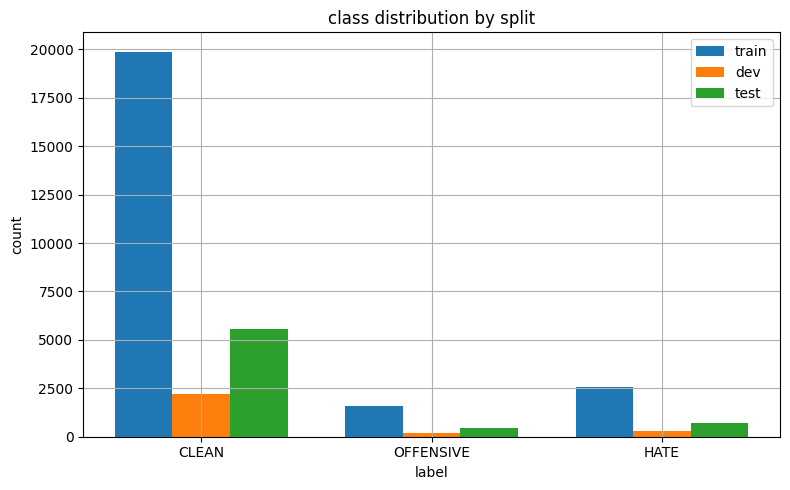

WindowsPath('C:/Users/23110/OneDrive/Desktop/3rd_Year/HK2/Đợt 1/MAAI/From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation/results/figures/eda_class_distribution_by_split.png')

In [12]:
splits = ["train", "dev", "test"]
labels = sorted(full_df[LABEL_COL].dropna().unique())
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8, 5))
for i, split in enumerate(splits):
    counts = (
        label_count_df[label_count_df["split"] == split]
        .set_index(LABEL_COL)["count"]
        .reindex(labels, fill_value=0)
        .values
    )
    plt.bar(x + i * width, counts, width=width, label=split)

plt.xticks(x + width, [LABEL_MAP.get(int(v), f"UNKNOWN_{int(v)}") for v in labels])
plt.xlabel("label")
plt.ylabel("count")
plt.title("class distribution by split")
plt.legend()
finalize_plot("eda_class_distribution_by_split.png")

In [13]:
train_p = label_prop_df[label_prop_df["split"] == "train"].set_index(LABEL_COL)["proportion"].sort_index()
dev_p = label_prop_df[label_prop_df["split"] == "dev"].set_index(LABEL_COL)["proportion"].sort_index()
test_p = label_prop_df[label_prop_df["split"] == "test"].set_index(LABEL_COL)["proportion"].sort_index()

split_divergence_df = pd.DataFrame([
    {"pair": "train vs dev", "js_divergence": js_divergence(train_p.values, dev_p.values)},
    {"pair": "train vs test", "js_divergence": js_divergence(train_p.values, test_p.values)},
    {"pair": "dev vs test", "js_divergence": js_divergence(dev_p.values, test_p.values)},
]).sort_values("js_divergence")

split_divergence_df

,pair,js_divergence
1,train vs test,0.000022
2,dev vs test,0.000443
0,train vs dev,0.000449


In [14]:
save_df(label_count_df, "eda_label_counts.csv")
save_df(label_prop_df, "eda_label_proportions.csv")
save_df(split_divergence_df, "eda_split_js_divergence.csv")

WindowsPath('C:/Users/23110/OneDrive/Desktop/3rd_Year/HK2/Đợt 1/MAAI/From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation/results/tables/eda_split_js_divergence.csv')

## 3. missing values, empty texts, duplicates, and leakage risk

In [15]:
train_feat = build_text_features(train_df)
dev_feat = build_text_features(dev_df)
test_feat = build_text_features(test_df)
full_feat = pd.concat([train_feat, dev_feat, test_feat], ignore_index=True)

quality_rows = []
for split, df in [("train", train_feat), ("dev", dev_feat), ("test", test_feat)]:
    quality_rows.append({
        "split": split,
        "rows": len(df),
        "null_text": int(df[TEXT_COL].isna().sum()),
        "empty_after_strip": int(df["empty_after_strip"].sum()),
        "exact_row_duplicates": int(df.duplicated().sum()),
        "duplicate_texts_exact": int(df[TEXT_COL].fillna("").duplicated().sum()),
        "duplicate_texts_norm": int(df["text_overlap_norm"].duplicated().sum()),
    })

quality_df = pd.DataFrame(quality_rows)
quality_df

,split,rows,null_text,empty_after_strip,exact_row_duplicates,duplicate_texts_exact,duplicate_texts_norm
0,train,24048,2,2,1356,1490,1518
1,dev,2672,0,0,21,22,22
2,test,6680,0,0,98,104,105


In [16]:
def overlap_stats(df_a, df_b, split_a, split_b, col):
    a = set(df_a[col].dropna().astype(str))
    b = set(df_b[col].dropna().astype(str))
    inter = a & b
    return {
        "pair": f"{split_a} vs {split_b}",
        "mode": col,
        "unique_overlap_count": len(inter),
        "overlap_rate_vs_left_unique": len(inter) / max(len(a), 1),
        "overlap_rate_vs_right_unique": len(inter) / max(len(b), 1),
    }

overlap_rows = []
pairs = [
    ("train", train_feat, "dev", dev_feat),
    ("train", train_feat, "test", test_feat),
    ("dev", dev_feat, "test", test_feat),
]
for left_name, left_df, right_name, right_df in pairs:
    overlap_rows.append(overlap_stats(left_df, right_df, left_name, right_name, TEXT_COL))
    overlap_rows.append(overlap_stats(left_df, right_df, left_name, right_name, "text_overlap_norm"))

overlap_df = pd.DataFrame(overlap_rows)
display(quality_df)
display(overlap_df)

,split,rows,null_text,empty_after_strip,exact_row_duplicates,duplicate_texts_exact,duplicate_texts_norm
0,train,24048,2,2,1356,1490,1518
1,dev,2672,0,0,21,22,22
2,test,6680,0,0,98,104,105


,pair,mode,unique_overlap_count,overlap_rate_vs_left_unique,overlap_rate_vs_right_unique
0,train vs dev,free_text,318,0.014098,0.120000
1,train vs dev,text_overlap_norm,319,0.014159,0.120377
2,train vs test,free_text,782,0.034668,0.118917
3,train vs test,text_overlap_norm,787,0.034931,0.119696
4,dev vs test,free_text,91,0.034340,0.013838
5,dev vs test,text_overlap_norm,92,0.034717,0.013992


In [17]:
conflict_df = (
    full_feat.groupby("text_overlap_norm")
    .agg(
        n_rows=(LABEL_COL, "size"),
        n_unique_labels=(LABEL_COL, "nunique"),
        labels=(LABEL_COL, lambda s: sorted(set(s))),
        example_text=(TEXT_COL, "first"),
        splits=("split", lambda s: sorted(set(s))),
    )
    .reset_index()
)

conflict_df = conflict_df[conflict_df["n_unique_labels"] > 1].sort_values(
    ["n_unique_labels", "n_rows"], ascending=[False, False]
)

print("texts with conflicting labels:", len(conflict_df))
conflict_df.head(20)

texts with conflicting labels: 241


,text_overlap_norm,n_rows,n_unique_labels,labels,example_text,splits
8,#error!,17,3,"[0, 1, 2]",#ERROR!,"[dev, test, train]"
45,- cả 2 cũng chỉ ngu như nhau thoii khỏi so sánh :)),3,3,"[0, 1, 2]",- cả 2 cũng chỉ ngu như nhau thoii khỏi so sánh :)),[train]
74,. ai khịa thầy là chetme đó nha,3,3,"[0, 1, 2]",. ai khịa thầy là chetme đó nha,"[test, train]"
13090,lee sin lol mẹ giáo án kiểm soát của thầy tú,3,3,"[0, 1, 2]",Lee Sin lol mẹ giáo án kiểm soát của thầy Tú,"[test, train]"
13359,loại nghiện game + săm trổ k có tương lai đâu nha,3,3,"[0, 1, 2]",Loại nghiện game + săm trổ k có tương lai đâu nha,"[dev, train]"
4156,chán,5,2,"[0, 1]",Chán,"[test, train]"
25940,vl,5,2,"[0, 1]",Vl,[train]
9657,già mà non,4,2,"[0, 1]",Già mà non,[train]
1002,abe chơi dơ,3,2,"[0, 2]",Abe chơi dơ,"[dev, test, train]"
1027,abe mua áo như này là chet con di me sela rồi =)),3,2,"[1, 2]",Abe mua áo như này là chet con di me sela rồi =)),"[dev, test, train]"


In [18]:
save_df(quality_df, "eda_data_quality.csv")
save_df(overlap_df, "eda_cross_split_overlap.csv")
save_df(conflict_df.head(500), "eda_label_conflicts_top500.csv")

WindowsPath('C:/Users/23110/OneDrive/Desktop/3rd_Year/HK2/Đợt 1/MAAI/From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation/results/tables/eda_label_conflicts_top500.csv')

## 4. text-length profile

In [19]:
length_summary = (
    full_feat.groupby(["split", LABEL_COL])
    .agg(
        rows=(TEXT_COL, "size"),
        char_len_mean=("char_len", "mean"),
        char_len_median=("char_len", "median"),
        word_len_mean=("word_len", "mean"),
        word_len_median=("word_len", "median"),
    )
    .reset_index()
)
length_summary["label_name"] = length_summary[LABEL_COL].map(LABEL_MAP)

length_summary[[
    "split", LABEL_COL, "label_name", "rows",
    "char_len_mean", "char_len_median",
    "word_len_mean", "word_len_median"
]]


,split,label_id,label_name,rows,char_len_mean,char_len_median,word_len_mean,word_len_median
0,dev,0,CLEAN,2190,43.629680,32.0,10.257078,7.0
1,dev,1,OFFENSIVE,212,44.103774,30.0,10.523585,7.0
2,dev,2,HATE,270,85.559259,57.0,20.462963,14.0
3,test,0,CLEAN,5548,43.713050,31.0,10.259553,7.0
4,test,1,OFFENSIVE,444,44.324324,32.0,10.693694,7.0
5,test,2,HATE,688,85.075581,60.0,20.328488,14.0
6,train,0,CLEAN,19886,45.272202,32.0,10.401136,7.0
7,train,1,OFFENSIVE,1606,44.054172,31.0,10.545455,7.0
8,train,2,HATE,2556,83.776995,59.0,20.048905,14.0


In [20]:
def plot_length_hist(df, length_col, title, xlabel, q=0.99, bins=60, save_name=None):
    plot_df = df[[length_col, "label_name"]].copy()
    plot_df = plot_df.dropna(subset=[length_col, "label_name"])

    upper = plot_df[length_col].quantile(q)
    plot_df[length_col] = plot_df[length_col].clip(upper=upper)

    plt.figure(figsize=(9, 5))
    sns.histplot(
        data=plot_df,
        x=length_col,
        hue="label_name",
        bins=bins,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        linewidth=2,
    )

    plt.xlim(0, upper)
    plt.title(f"{title} (clipped at {int(q * 100)}th percentile)")
    plt.xlabel(xlabel)
    plt.ylabel("density")
    plt.tight_layout()

    if save_name is not None:
        save_dir = os.path.dirname(save_name)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_name, dpi=200, bbox_inches="tight")

    plt.show()

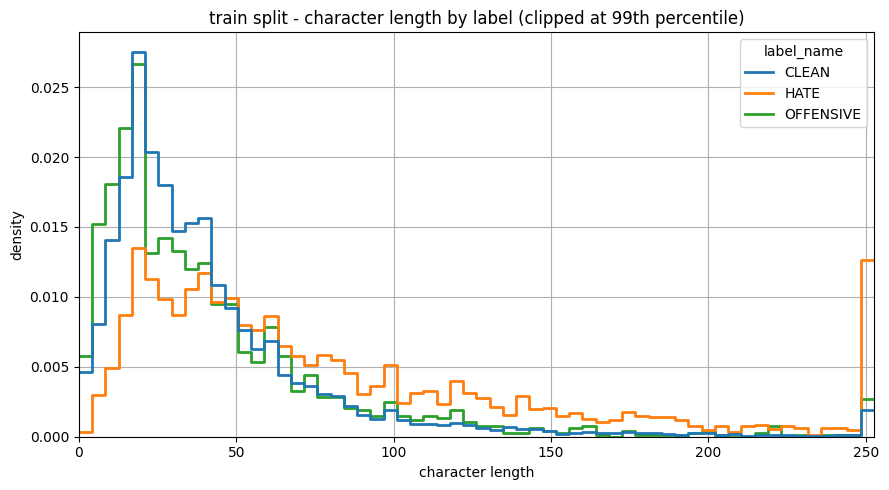

In [21]:
train_feat["label_name"] = train_feat["label_id"].map(LABEL_MAP)

plot_length_hist(
    train_feat,
    length_col="char_len",
    title="train split - character length by label",
    xlabel="character length",
    q=0.99,
    bins=60,
    save_name="../results/figures/train_char_length_by_label.png"
)

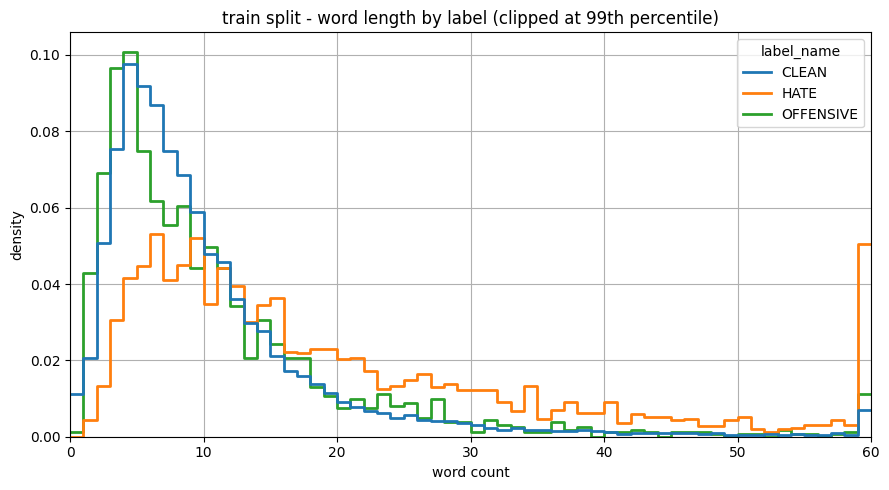

In [22]:
plot_length_hist(
    train_feat,
    length_col="word_len",
    title="train split - word length by label",
    xlabel="word count",
    q=0.99,
    bins=60,
    save_name="../results/figures/train_word_length_by_label.png"
)

In [23]:
save_df(length_summary, "eda_length_summary.csv")

WindowsPath('C:/Users/23110/OneDrive/Desktop/3rd_Year/HK2/Đợt 1/MAAI/From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation/results/tables/eda_length_summary.csv')

## 5. lexical analysis by class

In [24]:
def top_ngrams_by_class(df, label, ngram_range=(1, 1), top_k=15, min_df=3):
    subset = df.loc[df[LABEL_COL] == label, TEXT_COL].fillna("").astype(str)
    vec = CountVectorizer(
        lowercase=True,
        ngram_range=ngram_range,
        min_df=min_df,
        token_pattern=r"(?u)\b\w+\b",
    )
    X = vec.fit_transform(subset)
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    top_idx = counts.argsort()[::-1][:top_k]
    out = pd.DataFrame({
        "label_id": label,
        "label_name": LABEL_MAP.get(int(label), f"UNKNOWN_{int(label)}"),
        "ngram": vocab[top_idx],
        "count": counts[top_idx],
        "ngram_type": f"{ngram_range[0]}_{ngram_range[1]}",
    })
    return out

top_uni = []
top_bi = []
for label in sorted(train_feat[LABEL_COL].unique()):
    top_uni.append(top_ngrams_by_class(train_feat, label, ngram_range=(1, 1), top_k=15, min_df=5))
    top_bi.append(top_ngrams_by_class(train_feat, label, ngram_range=(2, 2), top_k=15, min_df=3))

top_uni_df = pd.concat(top_uni, ignore_index=True)
top_bi_df = pd.concat(top_bi, ignore_index=True)

display(top_uni_df.groupby("label_name").head(10))
display(top_bi_df.groupby("label_name").head(10))


,label_id,label_name,ngram,count,ngram_type
0,0,CLEAN,là,2426,1_1
1,0,CLEAN,có,2356,1_1
2,0,CLEAN,anh,1750,1_1
3,0,CLEAN,mà,1630,1_1
4,0,CLEAN,cho,1544,1_1
5,0,CLEAN,đi,1504,1_1
6,0,CLEAN,này,1395,1_1
7,0,CLEAN,thì,1343,1_1
8,0,CLEAN,em,1215,1_1
9,0,CLEAN,của,1140,1_1


,label_id,label_name,ngram,count,ngram_type
0,0,CLEAN,thuyết phục,325,2_2
1,0,CLEAN,https www,319,2_2
2,0,CLEAN,facebook com,317,2_2
3,0,CLEAN,www facebook,317,2_2
4,0,CLEAN,việt nam,226,2_2
5,0,CLEAN,cực kì,224,2_2
6,0,CLEAN,kì thuyết,189,2_2
7,0,CLEAN,trần dần,182,2_2
8,0,CLEAN,acc clone,172,2_2
9,0,CLEAN,các bạn,145,2_2


In [25]:
save_df(top_uni_df, "eda_top_unigrams_by_label.csv")
save_df(top_bi_df, "eda_top_bigrams_by_label.csv")

WindowsPath('C:/Users/23110/OneDrive/Desktop/3rd_Year/HK2/Đợt 1/MAAI/From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation/results/tables/eda_top_bigrams_by_label.csv')

In [26]:
chi_vec = CountVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=5,
    token_pattern=r"(?u)\b\w+\b",
)
X_train_chi = chi_vec.fit_transform(train_feat[TEXT_COL].fillna("").astype(str))
y_train = train_feat[LABEL_COL].values
feature_names = np.array(chi_vec.get_feature_names_out())

chi_rows = []
for label in sorted(np.unique(y_train)):
    y_one_vs_rest = (y_train == label).astype(int)
    scores, pvals = chi2(X_train_chi, y_one_vs_rest)
    top_idx = np.argsort(scores)[::-1][:20]
    chi_rows.append(pd.DataFrame({
        "label_id": label,
        "label_name": LABEL_MAP.get(int(label), f"UNKNOWN_{int(label)}"),
        "term": feature_names[top_idx],
        "chi2_score": scores[top_idx],
        "p_value": pvals[top_idx],
    }))

chi_df = pd.concat(chi_rows, ignore_index=True)
chi_df.groupby("label_name").head(10)


,label_id,label_name,term,chi2_score,p_value
0,0,CLEAN,ngu,909.223305,9.700551e-200
1,0,CLEAN,nó,883.644409,3.526677e-194
2,0,CLEAN,thằng,865.707013,2.798112e-190
3,0,CLEAN,đéo,849.111203,1.134470e-186
4,0,CLEAN,cái,794.344152,9.156927e-175
5,0,CLEAN,chó,785.113851,9.302846e-173
6,0,CLEAN,mẹ,715.432710,1.317685e-157
7,0,CLEAN,mày,711.093020,1.157393e-156
8,0,CLEAN,con,682.420371,1.988746e-150
9,0,CLEAN,lồn,680.357716,5.586432e-150


In [27]:
save_df(chi_df, "eda_top_chi2_terms_by_label.csv")

WindowsPath('C:/Users/23110/OneDrive/Desktop/3rd_Year/HK2/Đợt 1/MAAI/From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation/results/tables/eda_top_chi2_terms_by_label.csv')

## 6. concise EDA conclusions

In [28]:
eda_takeaways = [
    "the dataset is strongly imbalanced, so macro f1 should be the main metric later",
    "the official split is stable across train, dev, and test, so we can trust the provided split for phase 1",
    "duplicate texts and cross-split overlap are present, so final scores should be interpreted with some caution",
    "text length differs across labels, which suggests useful stylistic signal beyond raw word identity",
    "class-specific lexical cues are strong enough to justify tf-idf + linear baselines first",
]

takeaways_df = pd.DataFrame({"takeaway": eda_takeaways})
takeaways_df


,takeaway
0,"the dataset is strongly imbalanced, so macro f1 should be the main metric later"
1,"the official split is stable across train, dev, and test, so we can trust the provided split for phase 1"
2,"duplicate texts and cross-split overlap are present, so final scores should be interpreted with some caution"
3,"text length differs across labels, which suggests useful stylistic signal beyond raw word identity"
4,class-specific lexical cues are strong enough to justify tf-idf + linear baselines first


In [29]:
save_df(takeaways_df, "eda_takeaways.csv")
print("eda artifacts saved to:", RESULTS_DIR)

eda artifacts saved to: C:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation\results
